In [27]:
import nets
import copy
import numpy as np
import matplotlib.pyplot as plt

In [28]:
#Mismo sistema que para temporal difference pero sin politica definida

X = np.linspace(-5, 5, 101)   # estados discretos

def closest_state(x):
    return np.argmin(np.abs(X - x))

def step(x, u): #Recompensa un poco más sofisticada, añadiendo el parámetro done y una recompensa mayor si llega al objetivo
    x_next = x + u
    x_next = np.clip(x_next, -20, 20) 
    r = -x_next**2 - 0.05 * u**2
    done = (abs(x_next) < 0.05)
    if done:
        r += 50
    elif abs(x_next) > 9.5:
        r -= 50
        done = True
        
    return x_next, r, done

In [ ]:
buffer = nets.ReplayBuffer(5000, 1, 1)

Q = nets.DDPG_Critic(n_a = 1, n_s = 1)
Q_target = copy.deepcopy(Q)

pi = nets.DDPG_Actor(n_s = 1)
pi_target = copy.deepcopy(pi)


N = 20000
eps = 0.05
gamma = 0.95
lr_q = 0.001
lr_pi = 0.0001
batch_size = 64
update_rate = 2
tau = 0.99

hist_reward = []
Q_mean_history = []
Q_std_history = []

for i in range(N):
    x = np.random.uniform(-5.0,5.0)
    x = np.array([[x]])
    accum_reward = 0
    for t in range(40):

        u = np.clip(pi.forward(x) + np.random.normal(0, eps), -1, 1)

        x_next, r, done = step(x, u)
        accum_reward += r

        buffer.add(x, u, r, x_next, done)

        x = x_next

        if buffer.size > batch_size and t % update_rate == 0:
            batch = buffer.sample(batch_size)

            #Critic
            q = Q.forward(batch[0].T, batch[1].T)
            
            actions = pi_target.forward(batch[3].T)
            q_next = Q_target.forward(batch[3].T, actions)

            td_target = batch[2].T + gamma * (1 - batch[4].T) * q_next
            td_target = np.clip(td_target, -50, 50)

            q_target = td_target

            Q.backward(q_target)
            Q.update_weights(lr_q)

            # Actor

            a = pi.forward(batch[0].T)
            Q.forward(batch[0].T, a)
            dQ_da = Q.grad_a()
            dQ_da = np.clip(dQ_da, -10, 10)

            pi.backward(dQ_da)
            pi.update_weights(lr_pi)

            pi_target.soft_parameter_update(pi, tau)
            Q_target.soft_parameter_update(Q, tau)

            q_for_metric = Q.predict(batch[3].T, actions)
            Q_mean = np.mean(q)
            Q_std = np.std(q)

            Q_std_history.append(Q_std)
            Q_mean_history.append(Q_mean)

        if done:
            break

    hist_reward.append(accum_reward)

    



ValueError: matmul: Input operand 1 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

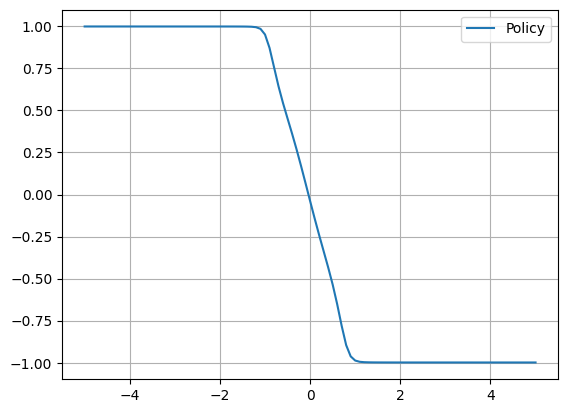

In [ ]:
policy = np.array([
    pi.forward(np.array([[x]]))
    for x in X
])

policy = policy.reshape(-1,1)

import matplotlib.pyplot as plt

plt.plot(X, policy)
plt.legend(["Policy"])
plt.grid()
plt.show()

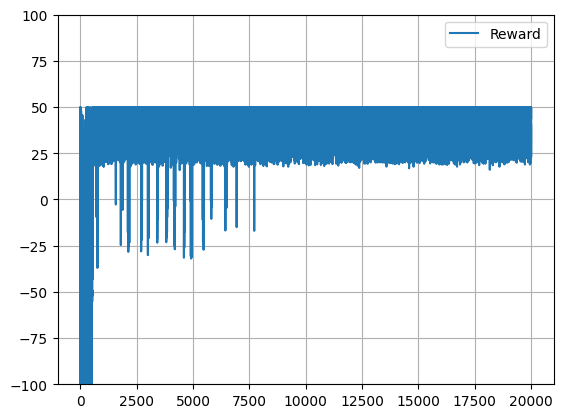

In [ ]:
i = np.arange(0, N)

hist_reward = np.array(hist_reward).reshape(np.array(hist_reward).shape[0])

plt.plot(i, np.array(hist_reward))
plt.legend(["Reward"])
plt.ylim(-100, 100)
plt.grid()
plt.show()

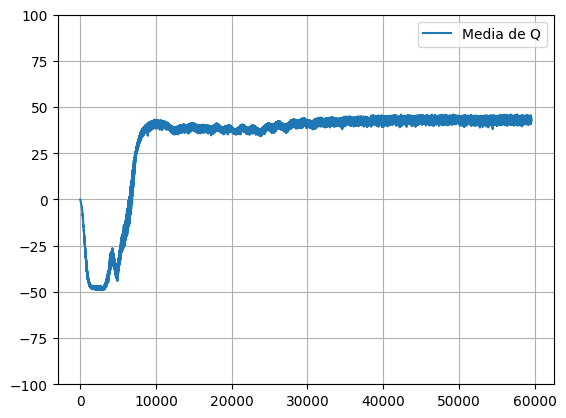

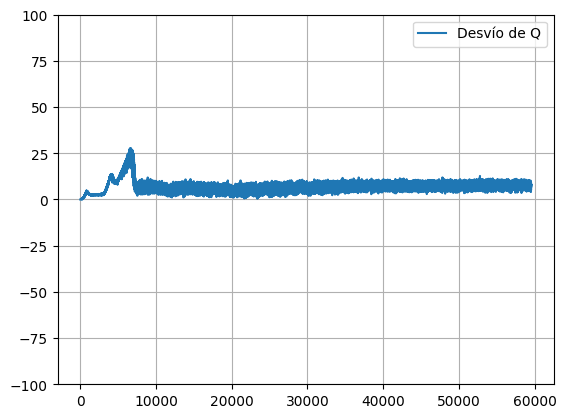

In [ ]:
t = np.arange(0, len(Q_mean_history))

Q_mean_history = np.array(Q_mean_history).reshape(np.array(Q_mean_history).shape[0])

plt.plot(t, np.array(Q_mean_history))
plt.legend(["Media de Q"])
plt.ylim(-100, 100)
plt.grid()
plt.show()

Q_std_history = np.array(Q_std_history).reshape(np.array(Q_std_history).shape[0])

plt.plot(t, np.array(Q_std_history))
plt.legend(["Desvío de Q"])
plt.ylim(-100, 100)
plt.grid()
plt.show()